In [6]:
import os

INPUT_DIR = '/kaggle/input/datasets/shreyash1110/acne04-yolov8' # Adjust if the folder name is slightly different

def print_directory_tree(startpath, max_depth=2):
    print(f"Scanning: {startpath}")
    for root, dirs, files in os.walk(startpath):
        depth = root[len(startpath):].count(os.sep)
        if depth > max_depth: continue
        indent = ' ' * 4 * depth
        print(f"{indent}📁 {os.path.basename(root)}/ ({len(files)} files)")
        if files:
            for f in files[:3]: print(f"{indent}    📄 {f}")
            if len(files) > 3: print(f"{indent}    ... and {len(files) - 3} more.")

print_directory_tree(INPUT_DIR)

Scanning: /kaggle/input/datasets/shreyash1110/acne04-yolov8
📁 acne04-yolov8/ (0 files)
    📁 labels/ (0 files)
        📁 content/ (0 files)
    📁 dataset/ (0 files)
        📁 labels/ (0 files)
        📁 Images/ (0 files)
    📁 Images/ (1457 files)
        📄 levle2_134.jpg
        📄 levle0_144.jpg
        📄 levle1_564.jpg
        ... and 1454 more.


In [7]:
import os

# Define our new paths based on your screenshot
BASE_DIR = '/kaggle/input/datasets/shreyash1110/acne04-yolov8/dataset'
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'Images/train')
TRAIN_LBL_DIR = os.path.join(BASE_DIR, 'labels/train')

# Get the first text file
sample_label_file = os.listdir(TRAIN_LBL_DIR)[0]
sample_label_path = os.path.join(TRAIN_LBL_DIR, sample_label_file)

print(f"Reading label file: {sample_label_file}\n")
with open(sample_label_path, 'r') as f:
    lines = f.readlines()
    for i, line in enumerate(lines):
        print(line.strip())
        if i >= 4: # Print only the first 5 lesions to avoid spamming the output
            print("... and more lesions")
            break
            
print(f"\nTotal lesions in this image: {len(lines)}")

Reading label file: levle1_19.txt

0 0.532423 0.477273 0.040956 0.054545
0 0.634812 0.461364 0.034130 0.050000
0 0.665529 0.504545 0.027304 0.054545
0 0.452218 0.359091 0.044369 0.054545
0 0.493174 0.652273 0.030717 0.068182
... and more lesions

Total lesions in this image: 8


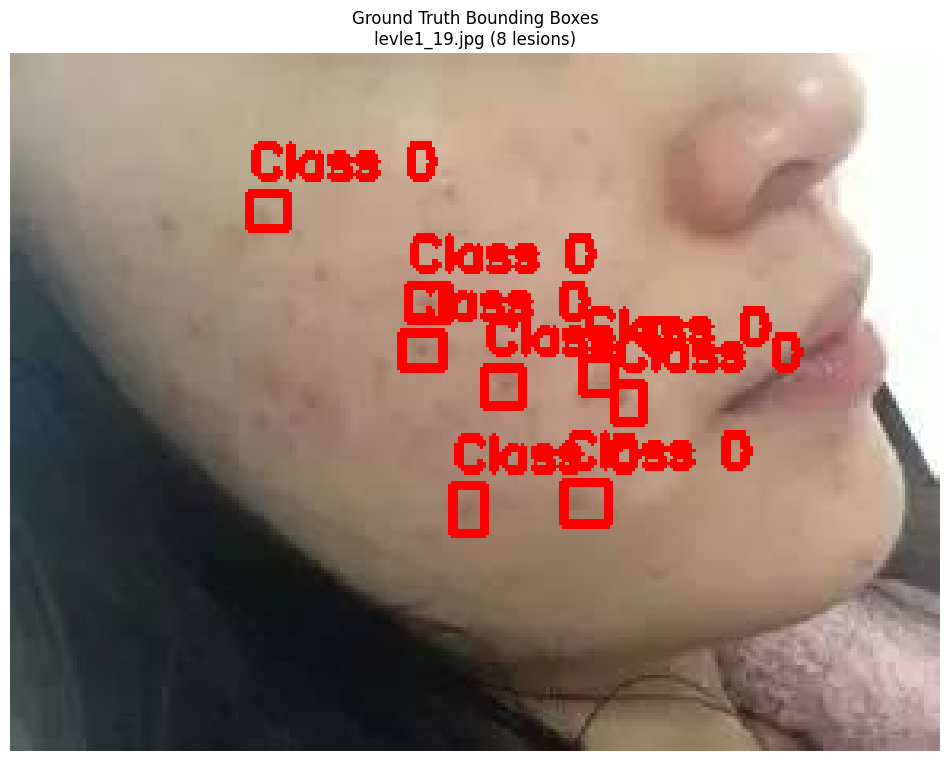

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def plot_yolo_bounding_boxes(image_path, label_path):
    # 1. Load the image using OpenCV (BGR format) and convert to RGB
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error loading image: {image_path}")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_height, img_width = img.shape[:2]

    # 2. Read the labels
    try:
        with open(label_path, 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"No label file found for {image_path}")
        return

    # 3. Draw each bounding box
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5: continue
            
        class_id = int(parts[0])
        x_center_norm, y_center_norm, w_norm, h_norm = map(float, parts[1:])

        # Convert YOLO normalized coordinates back to absolute pixel values
        x_center = x_center_norm * img_width
        y_center = y_center_norm * img_height
        box_width = w_norm * img_width
        box_height = h_norm * img_height

        # Calculate top-left and bottom-right coordinates for OpenCV
        x_min = int(x_center - (box_width / 2))
        y_min = int(y_center - (box_height / 2))
        x_max = int(x_center + (box_width / 2))
        y_max = int(y_center + (box_height / 2))

        # Draw the rectangle (Red color, 2px thickness)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
        
        # Put the class label text
        cv2.putText(img, f"Class {class_id}", (x_min, y_min - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # 4. Plot the image
    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Ground Truth Bounding Boxes\n{os.path.basename(image_path)} ({len(lines)} lesions)")
    plt.show()

# Let's visualize the exact image corresponding to the label file we looked at in Step 4
sample_img_file = sample_label_file.replace('.txt', '.jpg')
sample_img_path = os.path.join(TRAIN_IMG_DIR, sample_img_file)

plot_yolo_bounding_boxes(sample_img_path, sample_label_path)